<a href="https://colab.research.google.com/github/kadija-kru/d-tection_ransomware/blob/main/notebooks/00_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00_EDA: Exploratory Data Analysis (EDA)

The output shows the number of occurrences for each unique value in the 'Prediction' column. In this case, 'SS' appears 111904 times.

In [3]:
# 1️⃣ Load dataset
import pandas as pd
df = pd.read_csv('/content/UGRansome_Dataset_2024 (1).csv')
display(df.head())

,Time,Protocol,Flag,Family,Clusters,SeedAddress,ExpAddress,BTC,USD,Netflow_Bytes,IPaddress,Threats,Port,Prediction
0,58,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,500,5,A,Botnet,5061,SS
1,48,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,504,8,A,Botnet,5061,SS
2,38,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,508,7,A,Botnet,5061,SS
3,28,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,512,15,A,Botnet,5061,SS
4,49,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,520,17,A,Botnet,5061,SS


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving UGRansome_Dataset_2024 (1).csv to UGRansome_Dataset_2024 (1).csv
User uploaded file "UGRansome_Dataset_2024 (1).csv" with length 7562883 bytes


In [ ]:
# 2️⃣ Inspect features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111904 entries, 0 to 111903
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Time           111904 non-null  int64 
 1   Protocol       111904 non-null  object
 2   Flag           111904 non-null  object
 3   Family         111904 non-null  object
 4   Clusters       111904 non-null  int64 
 5   SeedAddress    111904 non-null  object
 6   ExpAddress     111904 non-null  object
 7   BTC            111904 non-null  int64 
 8   USD            111904 non-null  int64 
 9   Netflow_Bytes  111904 non-null  int64 
 10  IPaddress      111904 non-null  object
 11  Threats        111904 non-null  object
 12  Port           111904 non-null  int64 
 13  Prediction     111904 non-null  object
dtypes: int64(6), object(8)
memory usage: 12.0+ MB


In [ ]:
# 3️⃣ Summary statistics
df.describe()

,Time,Clusters,BTC,USD,Netflow_Bytes,Port
count,111904.000000,111904.000000,111904.000000,111904.000000,111904.000000,111904.000000
mean,27.580846,1.224317,17.464791,10278.888172,1916.683943,5063.898038
std,14.194556,0.456005,21.647918,11087.702928,1856.283852,2.675616
min,0.000000,1.000000,1.000000,1.000000,3.000000,5061.000000
25%,16.000000,1.000000,6.000000,828.000000,401.000000,5061.000000
50%,25.000000,1.000000,11.000000,5108.000000,1163.000000,5062.000000
75%,37.000000,1.000000,22.000000,18454.000000,3151.000000,5066.000000
max,61.000000,3.000000,183.000000,50991.000000,6780.000000,5068.000000


In [ ]:
# 4️⃣ Check missing values
df.isnull().sum()

,0
Time,0
Protocol,0
Flag,0
Family,0
Clusters,0
SeedAddress,0
ExpAddress,0
BTC,0
USD,0
Netflow_Bytes,0


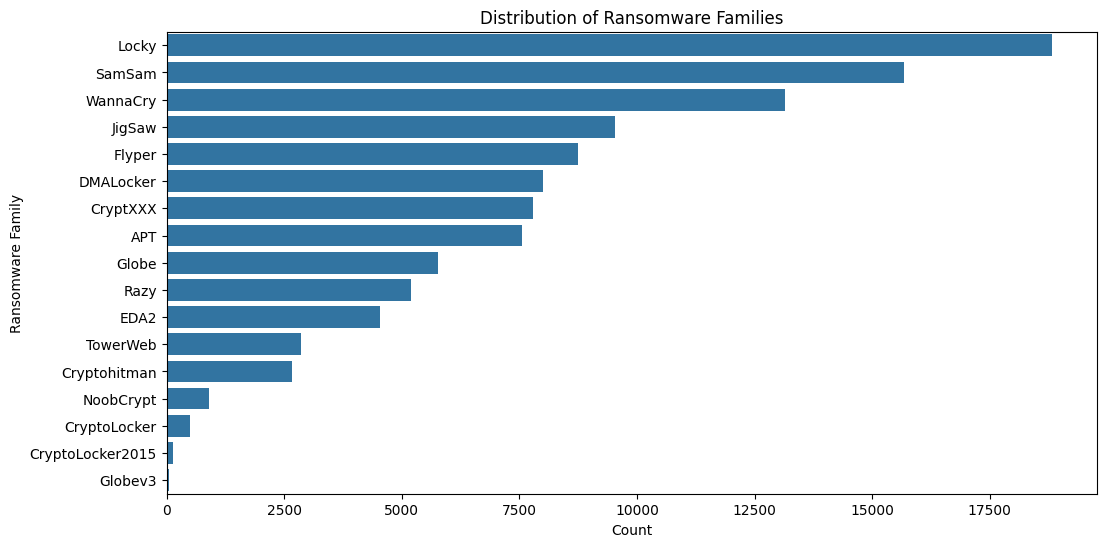

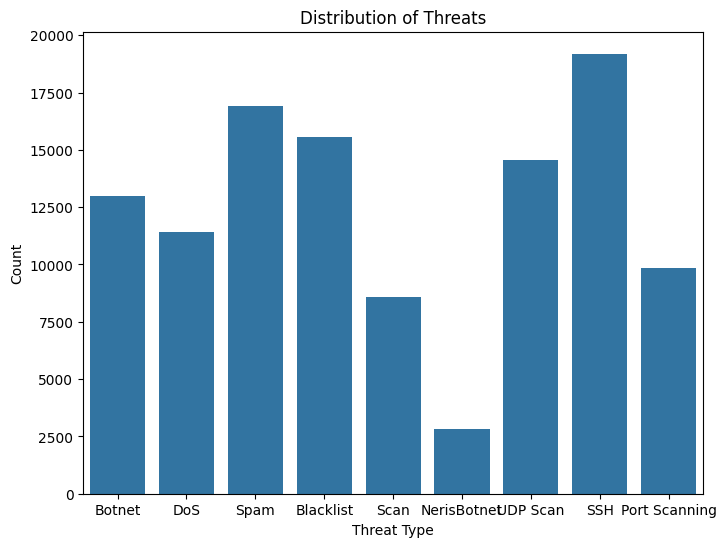

In [ ]:
# 5️⃣ Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#  Distribution of 'Family'
plt.figure(figsize=(12, 6))
sns.countplot(y='Family', data=df, order = df['Family'].value_counts().index)
plt.title('Distribution of Ransomware Families')
plt.xlabel('Count')
plt.ylabel('Ransomware Family')
plt.show()

#  Distribution of 'Threats'
plt.figure(figsize=(8, 6))
sns.countplot(x='Threats', data=df)
plt.title('Distribution of Threats')
plt.xlabel('Threat Type')
plt.ylabel('Count')
plt.show()

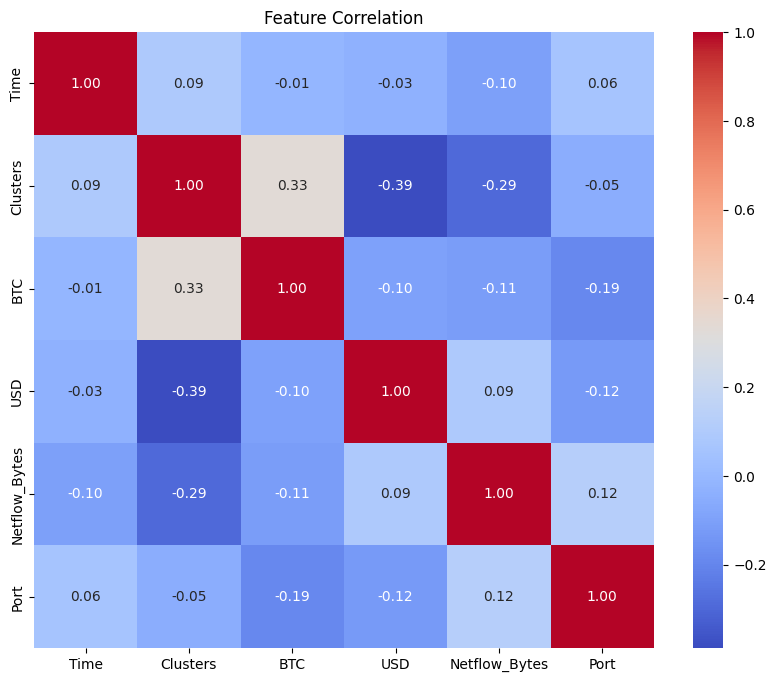

In [ ]:
# 6️⃣  feature correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [4]:
# Get the value counts for the 'Prediction' column
prediction_counts = df['Prediction'].value_counts()
display(prediction_counts)

,count
Prediction,
S,51738
SS,34158
A,26008


In [5]:
df["risk"] = df["Prediction"].apply(lambda x: 0 if x == "A" else 1)
df["risk"].value_counts()


,count
risk,
1,85896
0,26008
